In [130]:
import numpy as np 
from sklearn.model_selection import train_test_split
#导入线性模型和多项式特征构造模块
from sklearn import  linear_model
from sklearn.preprocessing import  PolynomialFeatures
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
%matplotlib inline

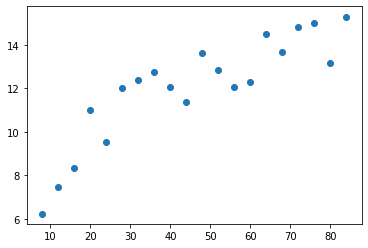

In [131]:
n_samples = 20
x = np.array([i+2 for i in range(n_samples)]) * 4
y = 3 * np.log(x) + np.random.randint(0,3,n_samples)
plt.scatter(x,y)

In [132]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3)

In [137]:
def poly_fit(degree):
    poly_reg =PolynomialFeatures(degree=degree)
    # 转换成二次特征
    x_ploy_train = poly_reg.fit_transform(x_train.reshape(-1,1))
    x_ploy_test = poly_reg.transform(x_test.reshape(-1,1))
    clf = linear_model.LinearRegression()
    clf.fit(x_ploy_train,y_train.reshape(-1,1))
    plt.subplot(121)
    y_train_pred = clf.predict(x_ploy_train)
    sorted_indices = np.argsort(x_train)
    plt.plot(x_train[sorted_indices],y_train_pred[sorted_indices])
    plt.scatter(x_train,y_train)
    plt.subplot(122)
    y_test_pred = clf.predict(x_ploy_test)
    sorted_indices = np.argsort(x_test)
    plt.plot(x_test[sorted_indices],y_test_pred[sorted_indices])
    plt.scatter(x_test,y_test)
    print("Train R2 score",r2_score(y_train_pred,y_train))
    print("Test R2 score",r2_score(y_test_pred,y_test))

Train R2 score 0.8102748526150807
Test R2 score 0.7661602866338544


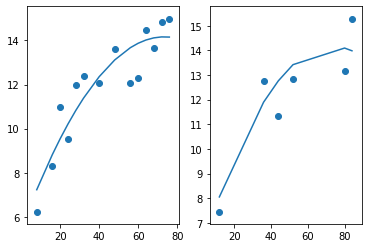

In [138]:
poly_fit(2)

Train R2 score 0.9087433750748772
Test R2 score 0.8326903541105737


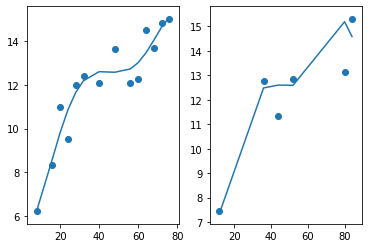

In [139]:
poly_fit(5)

Train R2 score 0.9176237285551411
Test R2 score -0.13339572778788056


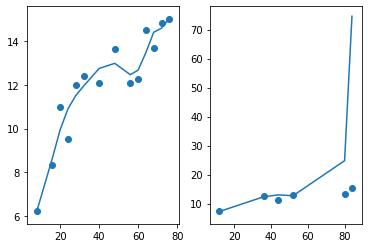

In [140]:
poly_fit(10)